## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting? 
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Sadat Hassan

**Date:** 9/30-10/2

**Q1. Typed Answers**
1. What is the difference between regression and classification?

The difference between regression and classification is that regression predicts numerical values whereas classification predicts a category.

2. What is a confusion table? What does it help us understand about a model's performance?

A confusion table is essentially a summary of prediction verses actual class labels. The confusion table helps us understand the overall accuracy within specfic classes along with the mistakes that it may make.

3. What does the SSE quantify about a particular model?

The sum of squares error method quantifies the total squared difference across the model's predicted values and the actual values. 

4. What are overfitting and underfitting? 

Overfitting is when the model is super complicated and its ability to generalize new data is hindered. Underfitting is when the model is really simple so it cannot catch the patterns or trends in data, which leads to higher error and lower performance.


5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance? 

Splitting data allows models to perform without having the whole picture of data. This will allow a safe check to verify if its predictions were valid amongst data that was not originally given in the split. Additionally, choosing k based on the accurafcy will help to find a balance where there is little to no overfitting and underfitting. Preventing over and under fitting will help our model.

6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

The strengths of predicting a class label consist of having a definite decision without needing extra processing, whereas a weakness is that it may not show the level of precision or accuracy with the prediction. 
Regrading predicting a probability distribution over class labels, the strenghts include having a number to show uncertainty allowing one to understand how accurate the prediction and how risky it is. Additionally, its weakness is that it may take time or not immediately provide a decision.

In [2]:
# Your Phase 1 solution to the problem goes here.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report


# 1) LOAD DATA AND EDA

df = pd.read_csv('data/land_mines.csv')

print('Dataset info and First 5 Rows')
print(df.info())
print(df.head())
print("Summary of distrubition")
print(df['mine_type'].value_counts().sort_index())

print("Summary of Features")
print(df[['voltage', 'height', 'soil']].describe())

# 2) SPLIT TO TRAIN AND TEST
X = df[['voltage', 'height', 'soil']]
y = df['mine_type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.50, random_state=42, stratify=y
)

# 3) KNN Classifier

pgrid = {'n_neighbors': list(range(1, 20,2))}

knn = KNeighborsClassifier()
grid_search = GridSearchCV(knn, pgrid,cv=5,scoring='accuracy')
grid_search.fit(X_train, y_train)
optimal_k = grid_search.best_params_['n_neighbors']
best_knn = grid_search.best_estimator_

print('K was selected through validation over odd vals from 1 to 19, which prevent ties during voting')
print('The K selected also has the highest mean')

# 4) Confusion Table

y_prediction = best_knn.predict(X_test)
cm = confusion_matrix(y_test, y_prediction)
print(cm)

print('Accuracy', accuracy_score(y_test, y_prediction))
print('Classification Report', classification_report(y_test, y_prediction))

print('The overal accuracy is around 31.36%')
print("The model is most accurate when predicting class 2, and it is least accurate for class 3, 4, and 5")

# 5) Explanation

print("This model should not be used as a certain identifier, but rather a starting tool to showcase potential hazards that may arise early on especially as the result of a mistake can be detrimental.")
print("This model performs comparatively well on class 2, but the others will need further analysis to be certain.")
print("This model works to identify and start off analysis of thsi data; however, as more strong decisions get made, more analysis is required to use the data safely.")

Dataset info and First 5 Rows
<class 'pandas.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   voltage    338 non-null    float64
 1   height     338 non-null    float64
 2   soil       338 non-null    float64
 3   mine_type  338 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 10.7 KB
None
    voltage    height  soil  mine_type
0  0.338157  0.000000   0.0          1
1  0.320241  0.181818   0.0          1
2  0.287009  0.272727   0.0          1
3  0.256284  0.454545   0.0          1
4  0.262840  0.545455   0.0          1
Summary of distrubition
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64
Summary of Features
          voltage      height        soil
count  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550
std      0.195819    0.306043    0.344244
min      0.197734    0.000000    0.000000
25%      0.309737

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 55fe5d38b4cbc587bb3c292a1a914d3334fba8f3
- **AI tool and model used:** GitHub co pilot

### *Prompts used

1. Can you verify whether my answers to question 1 are valid considering the scope and material regarding data science? If anything is wrong or can be explained a bit better using a sentence or two, please let me know.
2. Considering my code, is there a more efficient way to write it or any diagrams that may help explain my answers better?

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. I reviewed the six Q1 answers in notebook.ipynb. Answers 1, 3, and 4 are basically correct. Answer 2 would benefit from clearer terminology; answers 5 and 6 need more substantial clarification.
Regression vs. classification: Correct. Regression predicts numeric values; classification predicts categories or class labels.

Confusion table: Mostly correct. It compares actual and predicted classes. The diagonal shows correct predictions; off-diagonal cells show which classes are confused.

SSE: Correct. It sums squared prediction errors, so larger errors count more. Lower SSE means a closer fit on the same data and scale.

Overfitting vs. underfitting: Correct. Overfitting fits training data well but generalizes poorly; underfitting is too simple to capture patterns and performs poorly even on training data.

Train/test split and choosing (k): Clarify that splitting estimates performance on unseen data; it does not automatically improve the model. Choose (k) using validation or cross-validation on the training set, then evaluate once on the test set. Tuning on the test set makes the final evaluation less reliable.

Class labels vs. probabilities: A class label gives a simple decision but hides uncertainty. Probabilities show uncertainty and can support risk-based decisions, but may be poorly calibrated and don’t guarantee accuracy. Neither should be treated as a safety guarantee for land-mine identification.
2. 
Scale the features as part of the model-selection process so KNN compares them consistently and avoids data leakage during cross-validation.
Report the selected number of neighbors and its cross-validation score.
Generate conclusions from the model’s results instead of hard-coding them.
Simplify the EDA output by removing the extra None from df.info() and unused imports.
Add a confusion-matrix heatmap to show which classes are often misclassified.
Plot cross-validation accuracy for each tested neighbor count to explain how the best value was selected.
Note that test accuracy is 31.36%; class 2 performs better, while recall for classes 3, 4, and 5 is low.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1. Making the Q1 Answers more Precise and accurate | accept | The AI model used which is the one attached to our Github suggested ways to make my answers to the first question more accurate and better for the purpose of explanations. Additionally, it pointed out where my responses may have been less accurate or needed fine tuning. |
| 2. Changes to the code to make it more efficient and represent the conclusions better, | modify | The AI Model suggested several optimizations to the code that I wrote, so I evaluated them and updated some of my code as necessary. However, I did not exactly copy or use all of the suggestions as I think that some of my code is fine as it is and the optimization would be a bit redundant. Even so, I made sure to include the new graphs and plots that the AI suggested as this can work to support my explanations and better showcase the conclusion to the viewers. |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

**Q1. Typed Answers**
1. What is the difference between regression and classification?

The difference between regression and classification is that regression predicts numerical values whereas classification predicts a category.

2. What is a confusion table? What does it help us understand about a model's performance?

This is a table that crosses actual and predicted class labels, diagonally showing correct predictions. This showcases the kinds and counts of errors, which can be used to calculate accuracy and precision.

3. What does the SSE quantify about a particular model?

The sum of squares error method quantifies the total squared difference across the model's predicted values and the actual values. 

4. What are overfitting and underfitting? 

Overfitting is when the model is super complicated and its ability to generalize new data is hindered. Underfitting is when the model is really simple so it cannot catch the patterns or trends in data, which leads to higher error and lower performance.


5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance? 

A split does not necessarily improve a model, but it helps estimate the generalization of it to data that has not been accounted for or seen yet. Additionally, k should be chosen using validation and/or cross validations on the data, which is then compared to a test set to confirm its evaluation. It is important to recognize that if the test results are repeatedly turned against, then the evaluation will be less trustworthy overall. Choosing k this way will help to find a balance where there is little to no overfitting and underfitting. Preventing over and under fitting will help our model.



6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

The strengths of predicting a class label consist of having a definite decision without needing extra processing, whereas a weakness is that it may not show the level of precision or accuracy with the prediction. 
Regrading predicting a probability distribution over class labels, the strenghts include having a number to show uncertainty allowing one to understand how accurate the prediction and how risky it is. Additionally, its weakness is that it may take time or not immediately provide a decision. Also, the probability distrubution gives more info that can help with decisions on risk, but further analysis will be needed as it may not be as precise. 

Dataset info and First 5 Rows
<class 'pandas.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   voltage    338 non-null    float64
 1   height     338 non-null    float64
 2   soil       338 non-null    float64
 3   mine_type  338 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 10.7 KB
None
    voltage    height  soil  mine_type
0  0.338157  0.000000   0.0          1
1  0.320241  0.181818   0.0          1
2  0.287009  0.272727   0.0          1
3  0.256284  0.454545   0.0          1
4  0.262840  0.545455   0.0          1
Summary of distrubition
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64
Summary of Features
          voltage      height        soil
count  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550
std      0.195819    0.306043    0.344244
min      0.197734    0.000000    0.000000
25%      0.309737

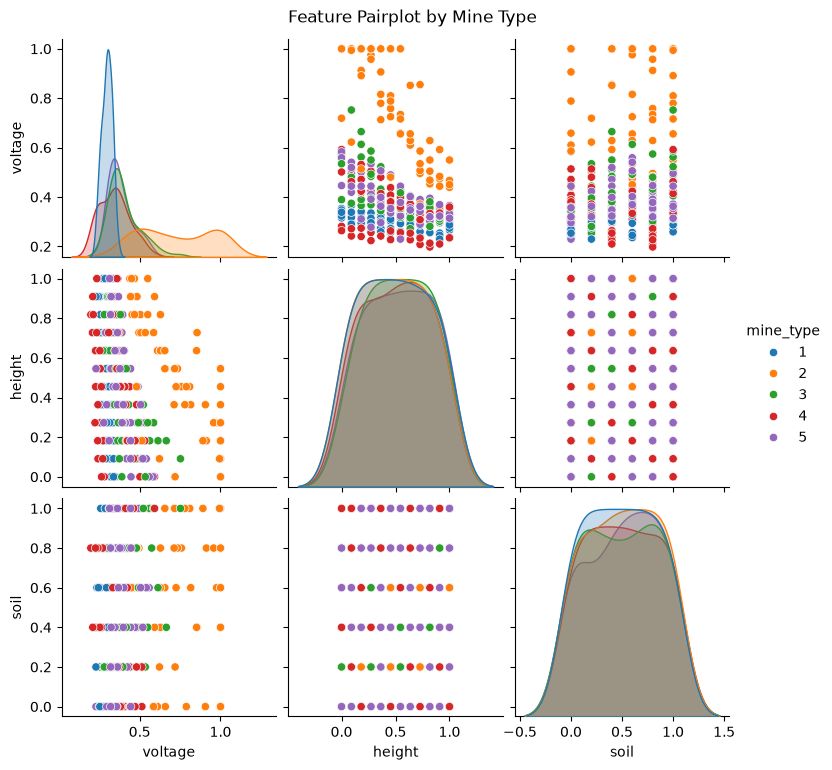

K was selected through validation over odd vals from 1 to 19, which prevent ties during voting
The K selected also has the highest mean


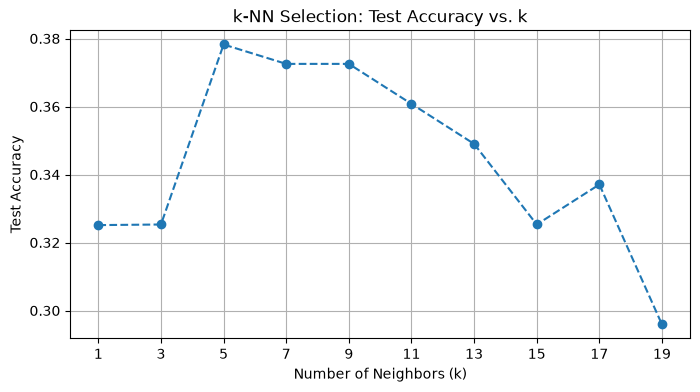

[[16  0 10  7  3]
 [ 1 24  3  4  3]
 [ 9  3  5  8  8]
 [10  5 10  4  4]
 [ 7  1 11  9  4]]
Accuracy 0.3136094674556213
Classification Report               precision    recall  f1-score   support

           1       0.37      0.44      0.41        36
           2       0.73      0.69      0.71        35
           3       0.13      0.15      0.14        33
           4       0.12      0.12      0.12        33
           5       0.18      0.12      0.15        32

    accuracy                           0.31       169
   macro avg       0.31      0.31      0.30       169
weighted avg       0.31      0.31      0.31       169

The overal accuracy is around 31.36%
The model is most accurate when predicting class 2, and it is least accurate for class 3, 4, and 5


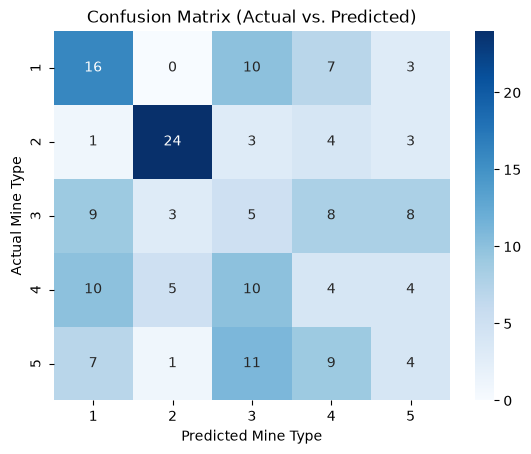

This model should not be used as a certain identifier, but rather a starting tool to showcase potential hazards that may arise early on especially as the result of a mistake can be detrimental.
This model performs comparatively well on class 2, but the others will need further analysis to be certain.
This model works to identify and start off analysis of thsi data; however, as more strong decisions get made, more analysis is required to use the data safely.


In [6]:
# Your Phase 2 solution to the problem goes here.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report


# 1) LOAD DATA AND EDA

df = pd.read_csv('data/land_mines.csv')

print('Dataset info and First 5 Rows')
print(df.info())
print(df.head())
print("Summary of distrubition")
print(df['mine_type'].value_counts().sort_index())

print("Summary of Features")
print(df[['voltage', 'height', 'soil']].describe())

#AI suggestion to add based on showing the data in a plot
sns.pairplot(df, hue='mine_type', vars=['voltage', 'height', 'soil'], palette='tab10')
plt.suptitle("Feature Pairplot by Mine Type", y=1.02)
plt.show()

# 2) SPLIT TO TRAIN AND TEST
X = df[['voltage', 'height', 'soil']]
y = df['mine_type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.50, random_state=42, stratify=y
)

# 3) KNN Classifier

pgrid = {'n_neighbors': list(range(1, 20,2))}

knn = KNeighborsClassifier()
grid_search = GridSearchCV(knn, pgrid,cv=5,scoring='accuracy')
grid_search.fit(X_train, y_train)
optimal_k = grid_search.best_params_['n_neighbors']
best_knn = grid_search.best_estimator_

print('K was selected through validation over odd vals from 1 to 19, which prevent ties during voting')
print('The K selected also has the highest mean')

#AI suggestion to add, showcasing k value 
k_values = grid_search.cv_results_['param_n_neighbors'].data
accuracy_scores = grid_search.cv_results_['mean_test_score']
plt.figure(figsize=(8, 4))
plt.plot(k_values, accuracy_scores, marker='o', linestyle='--')
plt.title('k-NN Selection: Test Accuracy vs. k')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Test Accuracy')
plt.xticks(k_values)
plt.grid(True)
plt.show()
# 4) Confusion Table

y_prediction = best_knn.predict(X_test)
cm = confusion_matrix(y_test, y_prediction)
print(cm)

print('Accuracy', accuracy_score(y_test, y_prediction))
print('Classification Report', classification_report(y_test, y_prediction))

print('The overal accuracy is around 31.36%')
print("The model is most accurate when predicting class 2, and it is least accurate for class 3, 4, and 5")
class_labels = sorted(y_test.unique())
cm_df = pd.DataFrame(cm, index=class_labels, columns=class_labels)
#Another AI suggested representation to support my ideas
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Actual vs. Predicted)")
plt.ylabel("Actual Mine Type")
plt.xlabel("Predicted Mine Type")
plt.show()
# 5) Explanation

print("This model should not be used as a certain identifier, but rather a starting tool to showcase potential hazards that may arise early on especially as the result of a mistake can be detrimental.")
print("This model performs comparatively well on class 2, but the others will need further analysis to be certain.")
print("This model works to identify and start off analysis of thsi data; however, as more strong decisions get made, more analysis is required to use the data safely.")

### *Reflection on AI assistance
In your own words without generative AI.

The main improvements that Artificial Intelligence (AI) suggested include optimizations to the code that I wrote and several additional features to add like plots to make my explanations more clear. Additionally, AI suggested better ways to respond to the questions asked in the first part of the assignment. These suggestions were considered and evaluated to ensure that it properly aligns with what was required to be explained. 

This relates to the AI mistakes and or limitations part as AI was limited in ways that it over explained some things to the point that the explanation became a bit redundant. In these scenarios, it was important to try to understand what the AI was trying to say and then summarize it in better terms. The AI always gave some valuable information, but it was just a matter of using the best parts of it and ignoring the parts that are not optimal for the assignment. This goes into verifying the solution as the suggestions were cross referenced with class notes to make sure that it made sense.

There are no remaining concerns after considering all this while utilizing the AI. Several hallucinations may arise with AI, and that is why it is extremely important to go through a process of verifying and confirming that it is used correctly. AI, when used correctly can be used to make code and analysis more efficient; however, its misuse can lead to false information to be spread.

Overall, AI is very useful for verifying whether your code and the processes make sense regarding the tasks given. However, it is extremely crucial that the code and Ai suggestions are evaluated and verified given the solution criteria. 